## Visualization of Spatially Continuous Reconstructions

## Loading Packages

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

import sys
sys.path.append("../../../")
from SpatialCOC.preprocess import preprocessing

## Loading Data

In [3]:
# name of slice
slices = ['ATAC', 'H3K4me3', 'H3K27ac', 'H3K27me3']

# Create a dictionary to store data for each slice
adata_dict = {}

for slice_name in slices:
    # file path
    rna_file_path = f"../../../Data/Mouse_Brain_{slice_name}/adata_RNA.h5ad"
    peaks_file_path = f"../../../Data/Mouse_Brain_{slice_name}/adata_peaks_normalized.h5ad"
    
    adata_modality_1 = sc.read_h5ad(rna_file_path)
    adata_modality_2 = sc.read_h5ad(peaks_file_path)
    
    # preprocessing
    print(f"Processing {slice_name} now!")
    adata_modality_1, adata_modality_2 = preprocessing(adata_modality_1, adata_modality_2, 'Spatial-epigenome-transcriptome')
    
    # storing
    adata_dict[slice_name] = {
        'adata_RNA': adata_modality_1,
        'adata_peaks_normalized': adata_modality_2
    }

Processing ATAC now!
Spatial-epigenome-transcriptome data preprocessing have done!
Dimensions after preprocessed adata_modal_1: (9196, 3000)
Dimensions after preprocessing adata_modal_2: (9196, 121068)
Processing H3K4me3 now!
Spatial-epigenome-transcriptome data preprocessing have done!
Dimensions after preprocessed adata_modal_1: (9513, 3000)
Dimensions after preprocessing adata_modal_2: (9513, 35270)
Processing H3K27ac now!
Spatial-epigenome-transcriptome data preprocessing have done!
Dimensions after preprocessed adata_modal_1: (9323, 3000)
Dimensions after preprocessing adata_modal_2: (9323, 104162)
Processing H3K27me3 now!
Spatial-epigenome-transcriptome data preprocessing have done!
Dimensions after preprocessed adata_modal_1: (9732, 3000)
Dimensions after preprocessing adata_modal_2: (9732, 70470)


## Calculating Smoothness

In [10]:
import numpy as np
import pandas as pd
import squidpy as sq
import uuid

# Create dictionaries to store the results for each slice
results_dict_RNA = {}
results_dict_EPI = {}

# Define the function to calculate Moran's I
def calculate_morans_i(adata_modality, modality_name):
    # Extract data and calculate mean for each spot/cell
    X1 = adata_modality.X
    if hasattr(X1, 'toarray'):  # Handle sparse matrices
        X1 = X1.toarray()
    X1_mean = np.mean(X1, axis=1)  # Mean expression per spot/cell

    X2 = adata_modality.uns['INR']
    if hasattr(X2, 'toarray'):  # Handle sparse matrices
        X2 = X2.toarray()
    X2_mean = np.mean(X2, axis=1)  # Mean expression per spot/cell

    # Create temporary columns in adata for Moran's I calculation
    temp_col_X1 = f"temp_X1_{uuid.uuid4().hex}"
    temp_col_X2 = f"temp_X2_{uuid.uuid4().hex}"
    
    adata_modality.obs[temp_col_X1] = X1_mean
    adata_modality.obs[temp_col_X2] = X2_mean
    
    # Construct the spatial graph
    try:
        sq.gr.spatial_neighbors(adata_modality, coord_type='generic')
    except:
        # If generic fails, try grid
        sq.gr.spatial_neighbors(adata_modality, coord_type='grid')
    
    moran_results = {}
    
    # Calculate Moran's I for X1 (RNA or EPI)
    try:
        sq.gr.spatial_autocorr(
            adata_modality,
            mode="moran",
            n_perms=100,
            attr="obs",
            genes=[temp_col_X1],
            n_jobs=4,
            seed=2024
        )
        moran_X1 = adata_modality.uns['moranI'].loc[temp_col_X1, 'I']
        moran_results[modality_name] = moran_X1
    except Exception as e:
        print(f"Error calculating Moran's I for {modality_name}: {e}")
        moran_results[modality_name] = None
    
    # Calculate Moran's I for INR
    try:
        sq.gr.spatial_autocorr(
            adata_modality,
            mode="moran",
            n_perms=100,
            attr="obs",
            genes=[temp_col_X2],
            n_jobs=4,
            seed=2024
        )
        moran_X2 = adata_modality.uns['moranI'].loc[temp_col_X2, 'I']
        moran_results['INR'] = moran_X2
    except Exception as e:
        print(f"Error calculating Moran's I for INR: {e}")
        moran_results['INR'] = None
    
    # Clean up temporary columns
    if temp_col_X1 in adata_modality.obs:
        del adata_modality.obs[temp_col_X1]
    if temp_col_X2 in adata_modality.obs:
        del adata_modality.obs[temp_col_X2]
    
    return moran_results

# Loop through each slice's data and calculate Moran's I for RNA data
print("Processing RNA data...")
for slice_name, data in adata_dict.items():
    adata_modality_1 = data['adata_RNA']  # RNA data
    
    # Calculate Moran's I
    moran_results = calculate_morans_i(adata_modality_1, 'RNA')
    
    # Print Moran's I information for the current slice
    print(f"Slice: {slice_name}")
    print(f"Moran's I for RNA: {moran_results.get('RNA', 'N/A')}")
    print(f"Moran's I for INR: {moran_results.get('INR', 'N/A')}")
    print()

    # Store the results in the dictionary
    results_dict_RNA[slice_name] = {
        'RNA': moran_results.get('RNA'),
        'INR': moran_results.get('INR')
    }

# Loop through each slice's data and calculate Moran's I for EPI data
print("Processing EPI data...")
for slice_name, data in adata_dict.items():
    adata_modality_2 = data['adata_peaks_normalized']  # EPI data
    
    # Calculate Moran's I
    moran_results = calculate_morans_i(adata_modality_2, 'EPI')
    
    # Print Moran's I information for the current slice
    print(f"Slice: {slice_name}")
    print(f"Moran's I for EPI: {moran_results.get('EPI', 'N/A')}")
    print(f"Moran's I for INR: {moran_results.get('INR', 'N/A')}")
    print()

    # Store the results in the dictionary
    results_dict_EPI[slice_name] = {
        'EPI': moran_results.get('EPI'),
        'INR': moran_results.get('INR')
    }

# Create summary DataFrames
moran_summary_RNA = pd.DataFrame.from_dict(results_dict_RNA, orient='index')
moran_summary_EPI = pd.DataFrame.from_dict(results_dict_EPI, orient='index')

print("RNA Moran's I Summary:")
print(moran_summary_RNA)
print("\nEPI Moran's I Summary:")
print(moran_summary_EPI)

# Save to Excel with different sheets
with pd.ExcelWriter('moran_summary.xlsx') as writer:
    moran_summary_RNA.to_excel(writer, sheet_name='RNA_Results')
    moran_summary_EPI.to_excel(writer, sheet_name='EPI_Results')

print("Results saved to 'moran_summary.xlsx'")

Processing RNA data...


  0%|          | 0/100 [00:00<?, ?/s]

  0%|          | 0/100 [00:00<?, ?/s]

Slice: ATAC
Moran's I for RNA: 0.5726459320582865
Moran's I for INR: 0.9416151727753987



  0%|          | 0/100 [00:00<?, ?/s]

...

  0%|          | 0/100 [00:00<?, ?/s]

Slice: H3K27ac
Moran's I for EPI: 0.26778055678528934
Moran's I for INR: 0.7646067979845128



  0%|          | 0/100 [00:00<?, ?/s]

  0%|          | 0/100 [00:00<?, ?/s]

Slice: H3K27me3
Moran's I for EPI: 0.30533128533918286
Moran's I for INR: 0.6811305235993297

RNA Moran's I Summary:
               RNA       INR
ATAC      0.572646  0.941615
H3K4me3   0.415429  0.906844
H3K27ac   0.433379  0.912711
H3K27me3  0.540626  0.934430

EPI Moran's I Summary:
               EPI       INR
ATAC      0.374078  0.805174
H3K4me3   0.325253  0.788599
H3K27ac   0.267781  0.764607
H3K27me3  0.305331  0.681131
Results saved to 'moran_summary.xlsx'


## Ploting

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Create a dictionary to store the results for each slice
results_dict = {}

# Define the function to calculate gradients
def calculate_gradients(adata_modality_1):
    # Extract data
    X1 = adata_modality_1.X
    X1 = np.sum(X1, axis=1)

    X2 = adata_modality_1.uns['INR']
    X2 = np.sum(X2, axis=1)

    coords = adata_modality_1.obsm['spatial']

    # Create DataFrame
    data_df = pd.DataFrame({
        'x': coords[:, 0],
        'X1': X1,
        'X2': X2
    })

    # Group by 'x' and sum
    sum_by_x = data_df.groupby('x')[['X1', 'X2']].sum().reset_index()

    # Normalize
    scaler = MinMaxScaler()
    sum_by_x[['X1', 'X2']] = scaler.fit_transform(sum_by_x[['X1', 'X2']])

    # Calculate gradients
    gradient_X1 = np.gradient(sum_by_x['X1'])
    gradient_X2 = np.gradient(sum_by_x['X2'])

    # Calculate absolute gradient values
    abs_gradient_X1 = np.abs(gradient_X1).sum()
    abs_gradient_X2 = np.abs(gradient_X2).sum()

    return sum_by_x, abs_gradient_X1, abs_gradient_X2

# Loop through each slice's data and calculate gradients
for slice_name, data in adata_dict.items():
    adata_modality_1 = data['adata_RNA']  # Assuming we use adata_RNA for calculations
    
    # Calculate gradients
    sum_by_x, abs_gradient_X1, abs_gradient_X2 = calculate_gradients(adata_modality_1)
    
    # Print gradient information for the current slice
    print(f"Slice: {slice_name}")
    print(f"Absolute Gradient X1: {abs_gradient_X1}")
    print(f"Absolute Gradient X2: {abs_gradient_X2}")
    print()

    # Store the results in the dictionary
    results_dict[slice_name] = {
        'sum_by_x': sum_by_x,
        'abs_gradient_X1': abs_gradient_X1,
        'abs_gradient_X2': abs_gradient_X2
    }

Slice: ATAC
Absolute Gradient X1: 4.9154729604586
Absolute Gradient X2: 3.34928229467236

Slice: H3K4me3
Absolute Gradient X1: 6.22466341946492
Absolute Gradient X2: 3.8888274080315357

Slice: H3K27ac
Absolute Gradient X1: 4.102195516368743
Absolute Gradient X2: 3.9591985675251324

Slice: H3K27me3
Absolute Gradient X1: 6.374758070169197
Absolute Gradient X2: 4.204938944467514



## Saving Results

In [8]:
import pandas as pd

output_path = 'gradient_results.xlsx'

# 创建 Excel writer
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for slice_name, result in results_dict.items():
        df = result['sum_by_x'].copy()

        safe_name = str(slice_name)[:31]
        for char in ['/', '\\', '[', ']', ':', '*', '?']:
            safe_name = safe_name.replace(char, '_')

        df.to_excel(writer, sheet_name=safe_name, index=False)

print(f"✓ Results saved to: {output_path}")
print(f"  Total sheets: {len(results_dict)}")

✓ Results saved to: gradient_results.xlsx
  Total sheets: 4


Plot the ATAC slice.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


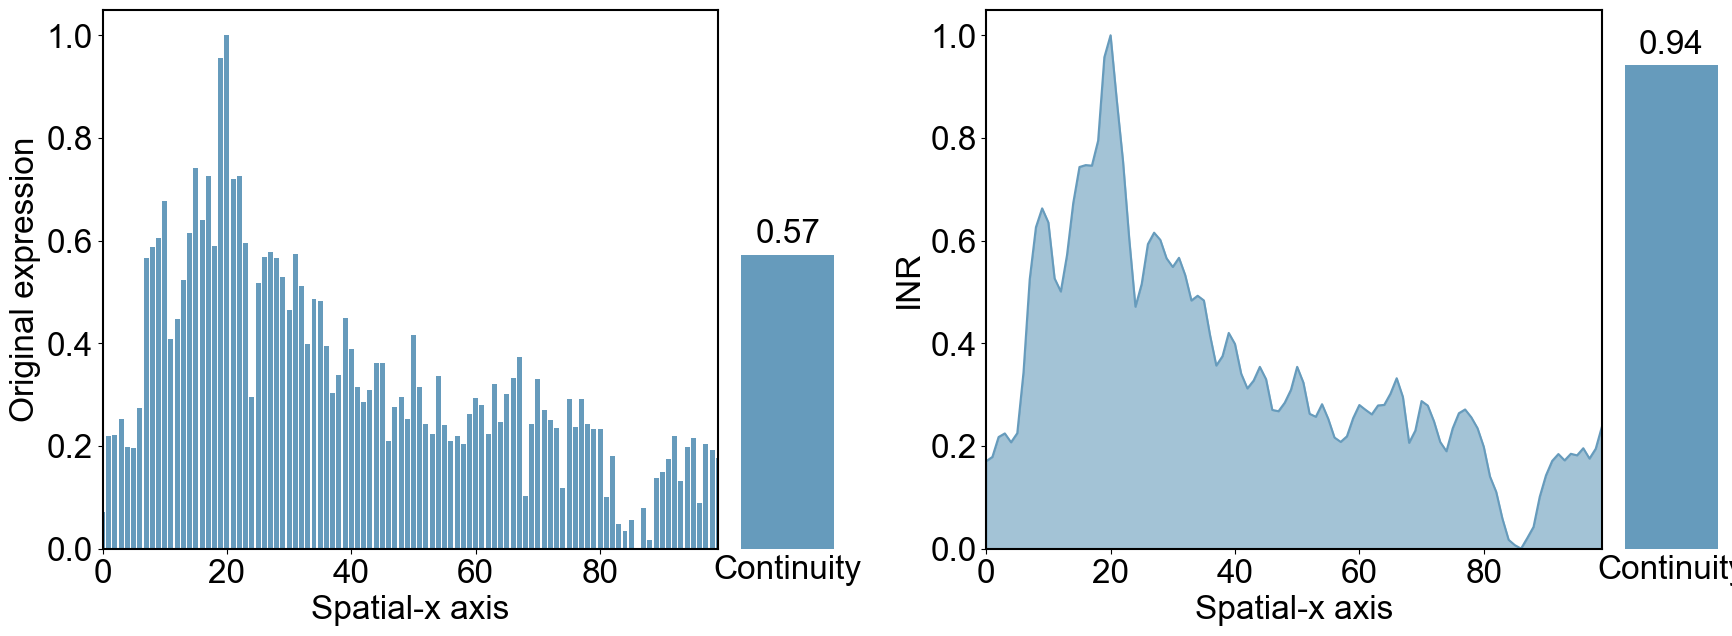

Plot the H3K4me3 slice.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


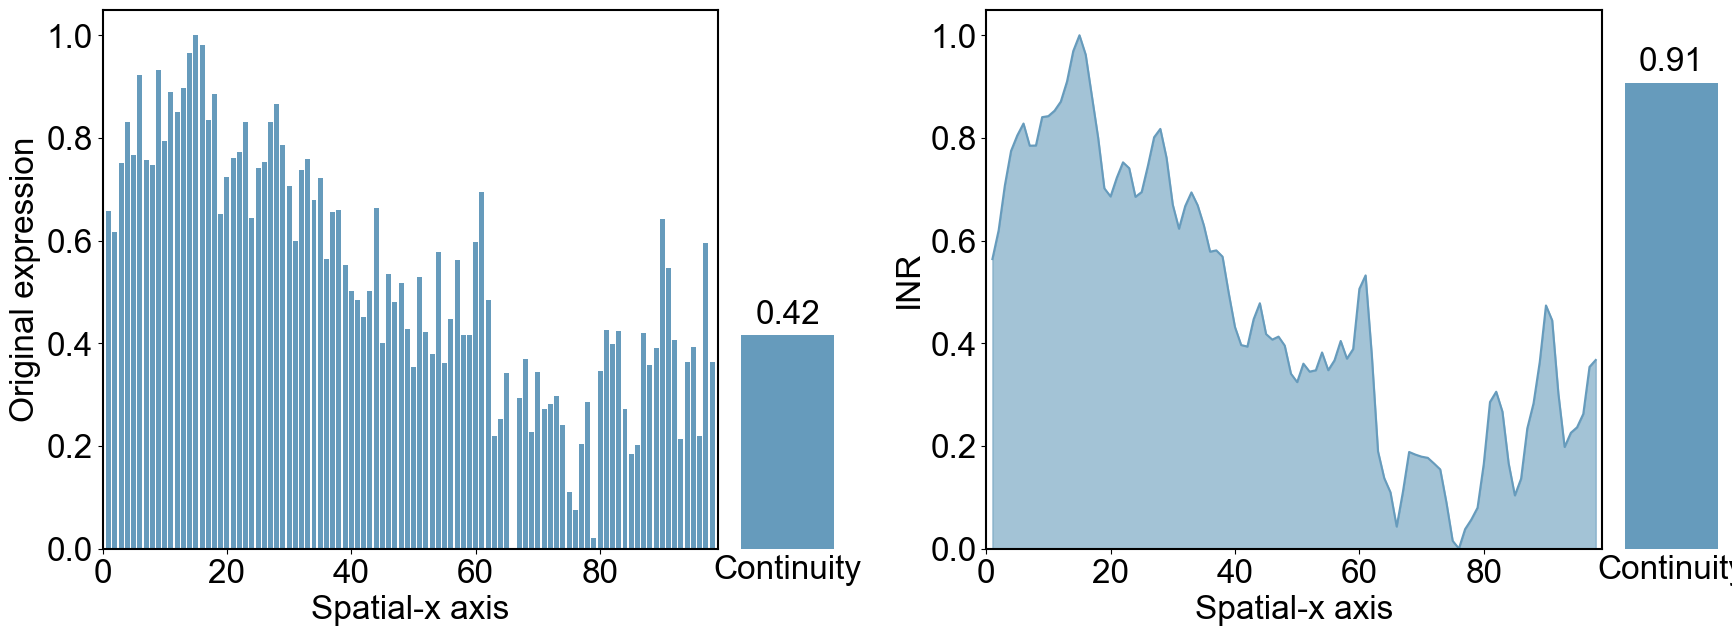

Plot the H3K27ac slice.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


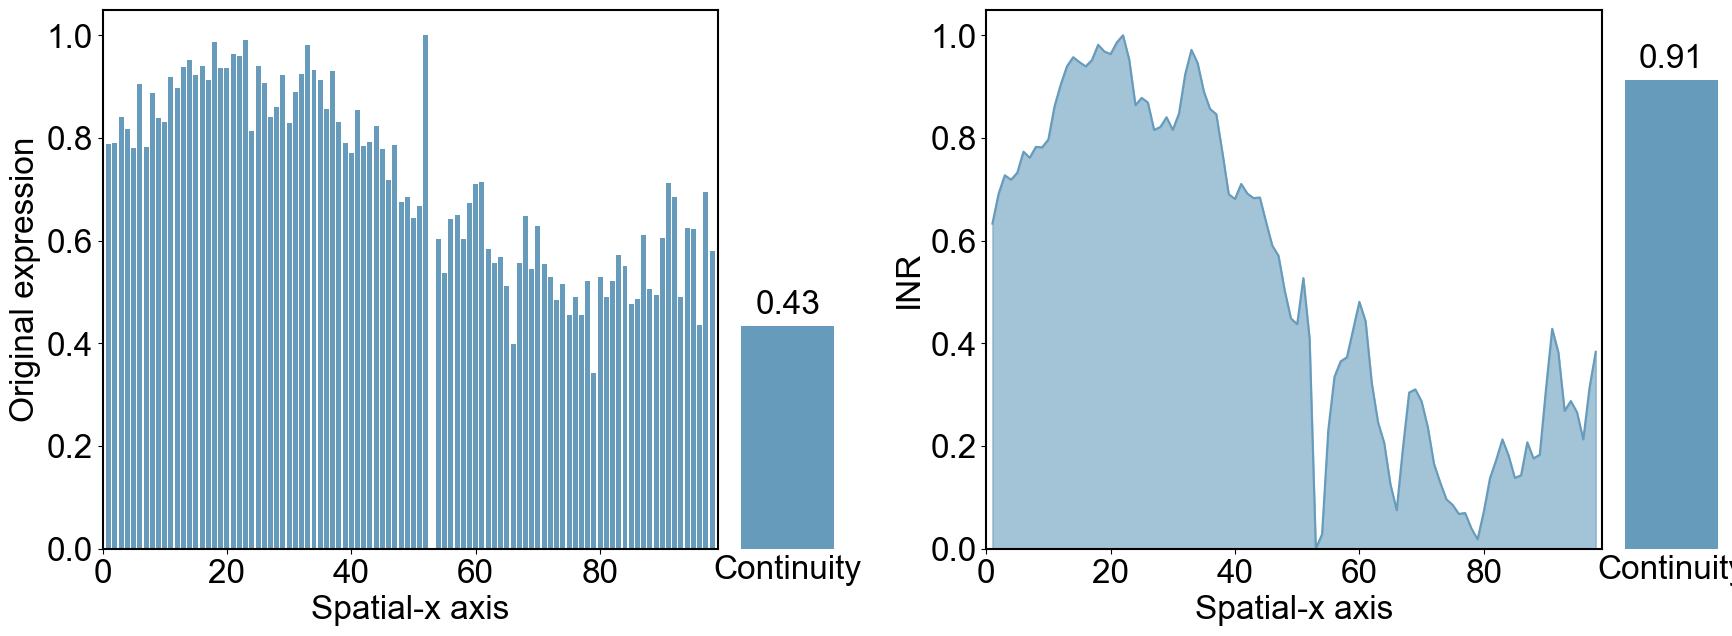

Plot the H3K27me3 slice.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


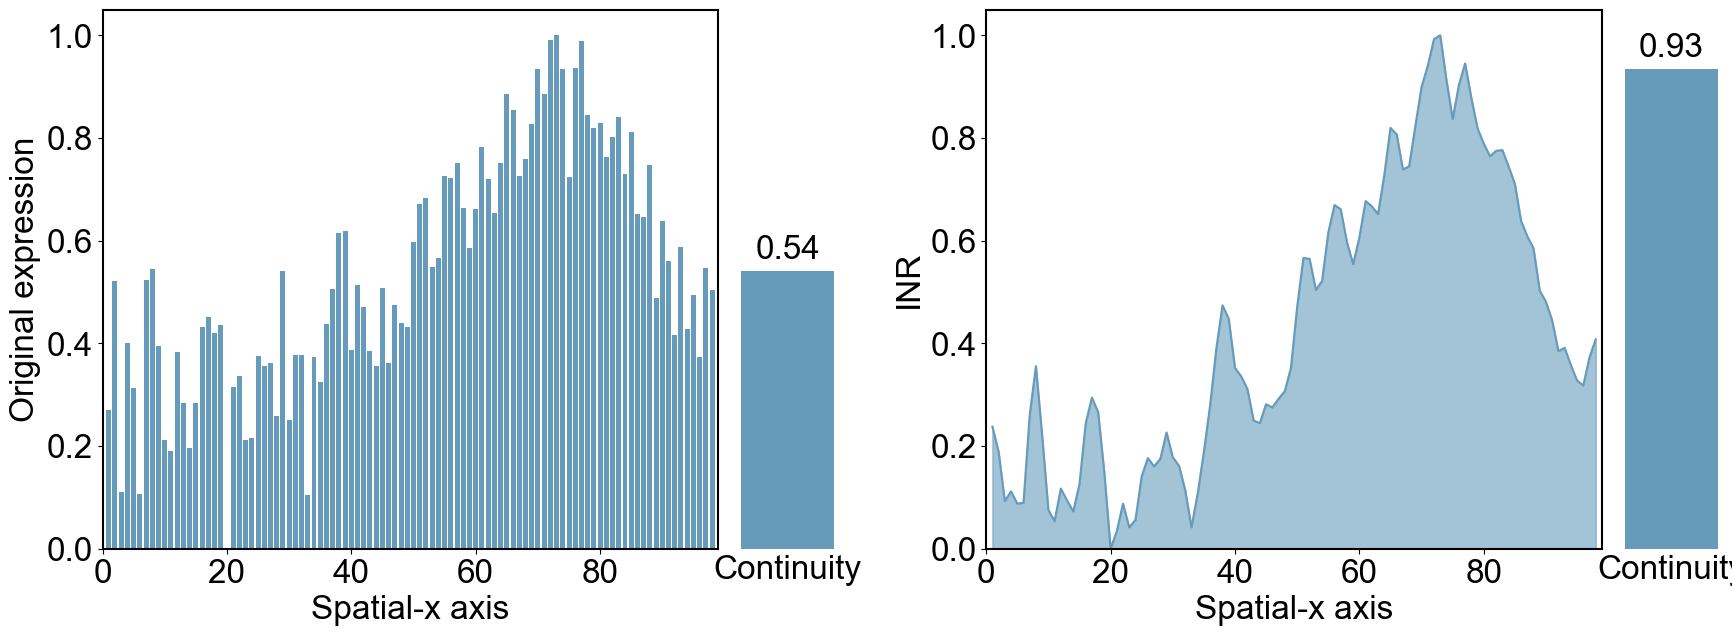

In [44]:
import pandas as pd

# 从Excel文件读取平滑度数据
moran_data = pd.read_excel('moran_summary.xlsx', sheet_name='RNA_Results', index_col=0)

for slice_name, results in results_dict.items():
    print(f"Plot the {slice_name} slice.")
    sum_by_x = results['sum_by_x']

    rna_smoothness = moran_data.loc[slice_name, 'RNA']
    inr_smoothness = moran_data.loc[slice_name, 'INR']

    # Create a figure
    fig = plt.figure(figsize=(18, 7))

    # Create an outer GridSpec to define the overall layout of the figure
    outer_gs = GridSpec(1, 2, width_ratios=[9, 9], wspace=0.2)

    # Create the first inner GridSpec, containing the first and second subplots
    inner_gs1 = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0], width_ratios=[6, 1], wspace=0.05)

    # Create the second inner GridSpec, containing the third and fourth subplots
    inner_gs2 = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[1], width_ratios=[6, 1], wspace=0.05)

    color = '#669bbc'

    # Set the global font to Arial and the global font size
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 24

    # Plot the first subplot: Bar chart of X1
    ax1 = fig.add_subplot(inner_gs1[0])
    ax1.bar(sum_by_x['x'], sum_by_x['X1'], color=color)
    ax1.set_xlabel('Spatial-x axis')
    ax1.set_ylabel('Original expression')
    ax1.set_ylim(0, 1.05)
    ax1.set_xlim(0, 99)
    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)

    # Plot the second subplot: Bar chart of the absolute gradient of X1
    ax2 = fig.add_subplot(inner_gs1[1])
    bar2 = ax2.bar(['X1'], [rna_smoothness], color=color)
    ax2.set_ylim(0, 1.05)
    ax2.set_xlabel('Continuity', fontsize=24)
    ax2.set_xticks([])
    ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    for bar in bar2:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

    # Plot the third subplot: Line chart of X2 with filled area under the curve
    ax3 = fig.add_subplot(inner_gs2[0])
    ax3.plot(sum_by_x['x'], sum_by_x['X2'], color=color, linestyle='-')
    ax3.fill_between(sum_by_x['x'], sum_by_x['X2'], color=color, alpha=0.6)
    ax3.set_xlabel('Spatial-x axis')
    ax3.set_ylabel('INR')
    ax3.set_ylim(0, 1.05)
    ax3.set_xlim(0, 99)
    for spine in ax3.spines.values():
        spine.set_linewidth(1.5)

    # Plot the fourth subplot: Bar chart of the absolute gradient of X2
    ax4 = fig.add_subplot(inner_gs2[1])
    bar4 = ax4.bar(['X2'], [inr_smoothness], color=color)
    ax4.set_ylim(0, 1.05)
    ax4.set_xlabel('Continuity', fontsize=24)
    ax4.set_xticks([])
    ax4.set_yticklabels([])
    ax4.set_yticks([])
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.spines['bottom'].set_visible(False)
    ax4.spines['left'].set_visible(False)
    # Display value labels above the bars
    for bar in bar4:
        yval = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

    plt.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.15)
    plt.suptitle('')

    plt.savefig(f'{slice_name}/INR_RNA.png', dpi=500)
    plt.savefig(f'{slice_name}/INR_RNA.eps')

    plt.show()